## What is The Most Optimal Skill to Learn for Data Scientists

### Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\baw61\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Clean Data

In [2]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()
df_DS_US_exploded = df_DS_US.explode('job_skills')
df_DS_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
9,NaN,sql
9,NaN,python
9,NaN,r
9,NaN,mongodb
9,NaN,mongodb


### Calculate Percent of Job Postings that Have Skills

In [11]:
df_DS_skills = (
    df_DS_US_exploded
    .groupby('job_skills')
    .agg(
        skill_count=('job_skills', 'size'),
        median_salary=('salary_year_avg', 'median')
    )

    .sort_values(by='skill_count', ascending=False)
)

DS_job_count = len(df_DS_US)
df_DS_skills['skill_percent'] = df_DS_skills['skill_count'] / DS_job_count * 100

skill_percent = 10

df_DS_skills_high_demand = df_DS_skills[df_DS_skills['skill_percent'] > skill_percent]
df_DS_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
python,42379,131867.0,72.036376
sql,30034,134500.0,51.052184
r,26022,126000.0,44.232534
sas,14340,120000.0,24.375319
tableau,13859,125000.0,23.557709
aws,10288,134000.0,17.487676
spark,9890,135959.5,16.811151
java,7335,125000.0,12.468129
tensorflow,7039,149646.0,11.964984


### Coloring by Technology

In [ ]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['excel',
  'ssis',
  'sheets',
  'tableau',
  'outlook',
  'alteryx',
  'nuix',
  'sap',
  'sas',
  'datarobot',
  'powerpoint',
  'power bi',
  'dax',
  'word',
  'msaccess',
  'looker',
  'spss',
  'sharepoint',
  'microstrategy',
  'qlik',
  'cognos',
  'ssrs',
  'visio',
  'ms access',
  'spreadsheet',
  'splunk',
  'esquisse',
  'powerbi'],
 'programming': ['lua',
  'visualbasic',
  'solidity',
  'bash',
  'apl',
  'html',
  'c++',
  'ruby',
  'sas',
  'clojure',
  'crystal',
  'vb.net',
  'powershell',
  'ocaml',
  'matlab',
  'swift',
  'javascript',
  'cobol',
  'typescript',
  'scala',
  't-sql',
  'julia',
  'mongodb',
  'dart',
  'lisp',
  'shell',
  'perl',
  'kotlin',
  'vba',
  'erlang',
  'assembly',
  'nosql',
  'r',
  'f#',
  'java',
  'go',
  'visual basic',
  'fortran',
  'groovy',
  'haskell',
  'golang',
  'no-sql',
  'c#',
  'mongo',
  'python',
  'objective-c',
  'delphi',
  'css',
  'c',
  'php',
  'sql',
  'elixir',
  'rust',
  'pascal',
  's

### Join DataFrames

In [19]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')
df_plot = df_DS_skills_high_demand.merge(df_technology, left_on='job_skills',right_on='skills')

### Ploting Findings on Scatterplot

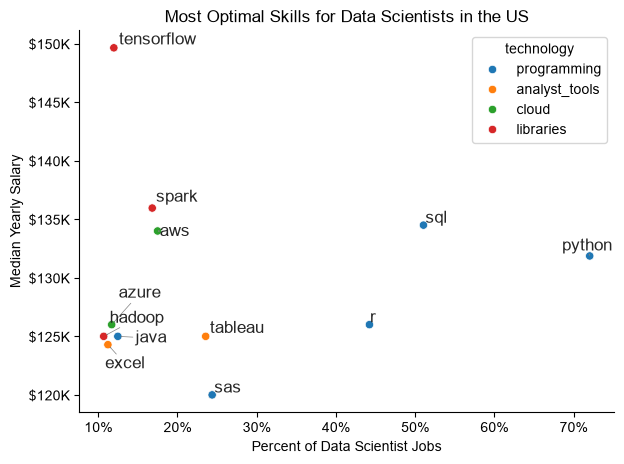

In [22]:
from adjustText import adjust_text

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)


sns.despine()
sns.set_theme(style='ticks')
texts = []
for i, txt in enumerate(df_DS_skills_high_demand.index):
    texts.append(plt.text(df_DS_skills_high_demand['skill_percent'].iloc[i], df_DS_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

from matplotlib.ticker import PercentFormatter 
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter())

plt.xlabel('Percent of Data Scientist Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Scientists in the US')


plt.tight_layout()
plt.show()